In [1]:
import torch
from torch import nn
from torch import optim
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

In [2]:
# Definição da classe da rede neural
class FashionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(784, 256) # Camada oculta 1
        self.hidden2 = nn.Linear(256, 128) # Camada oculta 2
        self.output = nn.Linear(128, 10) # Camada de saída
        self.log_softmax = nn.LogSoftmax(dim=1) # Softmax com log
        self.activation = nn.ReLU() # Função de ativação ReLU

    def forward(self, x):
        x = self.hidden1(x) # Passa pelos neurônios da primeira camada oculta
        x = self.activation(x) # Aplica a função de ativação ReLU
        x = self.hidden2(x) # Passa pelos neurônios da segunda camada oculta
        x = self.activation(x) # Aplica a função de ativação ReLU
        x = self.output(x) # Passa pelos neurônios da camada de saída
        output = self.log_softmax(x) # Aplica log_softmax
        return output

In [6]:
device = torch.device("cpu")

model = FashionNetwork()
model.load_state_dict(torch.load('fashion_mnist_model.pt', map_location=torch.device('cpu')))
model.to(device)  # Mover o modelo carregado para a GPU, se disponível

FashionNetwork(
  (hidden1): Linear(in_features=784, out_features=256, bias=True)
  (hidden2): Linear(in_features=256, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=10, bias=True)
  (log_softmax): LogSoftmax(dim=1)
  (activation): ReLU()
)

In [7]:
  import os
  import gzip
  import numpy as np

In [10]:
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(0.5, 0.5)
                              ])

# Baixar e carregar os dados de treinamento
trainset = datasets.FashionMNIST('Fashion_MNIST/', download=True,
                                 train=True, transform=transform)


# Baixar e carregar os dados de teste
testset = datasets.FashionMNIST('Fashion_MNIST/', download=True,
                                train=False, transform=transform)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


100.0%
100.0%
100.0%
100.0%


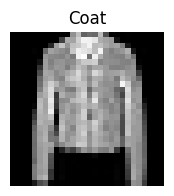

In [11]:
imagem, true_label =  testset[10]

plt.figure(figsize=(2, 2))

plt.imshow(imagem[0], cmap='gray')
plt.title(class_names[true_label])
plt.axis('off')
plt.show()

In [12]:
with torch.no_grad():
  imagem = imagem.view(1, -1)
  imagem = imagem.to(device)

  log_prob = model(imagem) # O modelo retorna o logaritmo do softmax
  prob = torch.exp(log_prob) # Não quero o logaritmo então passo exp(log(x)) = x

  print(prob) # O mais provavel foi o indice 4


  print(f'\nA classe inferida é: {class_names[torch.argmax(prob)]} com {torch.max(prob)*100:.2f}% de certeza.')

tensor([[2.6536e-03, 3.6810e-04, 3.1083e-01, 1.1968e-04, 6.6119e-01, 3.1198e-06,
         2.4808e-02, 2.9243e-06, 2.2674e-05, 4.2393e-06]])

A classe inferida é: Coat com 66.12% de certeza.


### Interface melhorada

In [13]:
# @title Texto de título padrão
import matplotlib.pyplot as plt
import numpy as np

def imshow(image, ax=None, title=None, normalize=True):
    # Cria a figura se não for especificado um eixo
    if ax is None:
        fig, ax = plt.subplots()

    # Transforma a imagem para o formato esperado pelo plt.imshow
    image = image.numpy().transpose((1, 2, 0))

    # Remove a dimensão extra se a imagem for preto e branco
    if image.shape[2] == 1:
        image = np.squeeze(image, axis=2)

    # Normaliza a imagem entre 0 e 1
    if normalize:
        mean = np.array([0.5])
        std = np.array([0.5])
        image = std * image + mean
        image = np.clip(image, 0, 1)

    # Mostra a imagem em escala de cinza
    ax.imshow(image, cmap='gray')

    # Remove as bordas e os ticks dos eixos
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.set_xticklabels('')
    ax.set_yticklabels('')

    return ax

def view_classify(img, ps):
    # Nomes das classes de roupas
    class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

    # Converte as probabilidades para um array numpy
    ps = ps.cpu().detach().numpy().squeeze()

    # Cria a figura com dois eixos
    fig, (ax1, ax2) = plt.subplots(figsize=(6, 9), ncols=2)

    # Mostra a imagem com o plt.imshow() e em escala de cinza
    ax1.imshow(img.view(28, 28).cpu().numpy(), cmap='gray')
    ax1.axis('off')

    # Adiciona as classes correta e prevista no gráfico
    predicted_label = np.argmax(ps)

    # Plota um gráfico de barras com as probabilidades
    ax2.barh(np.arange(10), ps, color='black')
    ax2.set_aspect(0.1)
    ax2.set_yticks(np.arange(10))
    ax2.set_yticklabels(class_names, size='small');
    ax2.set_title(class_names[predicted_label])
    ax2.set_xlim(0, 1.1)
    ax2.set_ylim(-0.5, 9.5)


    plt.tight_layout()

Verdade absoluta: Pullover


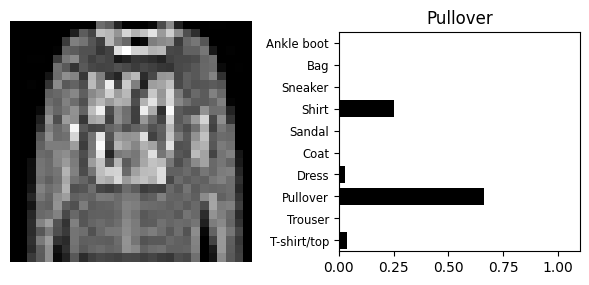

In [14]:
imagem, true_label = testset[500]

with torch.no_grad():
  imagem = imagem.view(1, -1)
  imagem = imagem.to(device)

  log_prob = model(imagem) # O modelo retorna o logaritmo do softmax
  prob = torch.exp(log_prob) # Não quero o logaritmo então passo exp(log(x)) = x

print(f'Verdade absoluta: {class_names[true_label]}')
view_classify(imagem.view(1, 28, 28), prob)

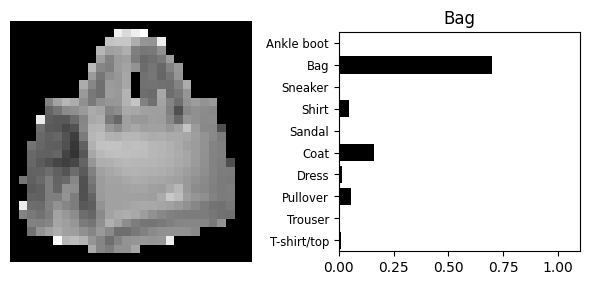

In [17]:
# @title Pegar uma imagem da internet
#from google.colab import files
from PIL import Image
import torch
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms

# Define as transformações aplicadas às imagens
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Faz o upload da imagem para a sessão atual
#uploaded = files.upload()


# Obtém o nome do arquivo carregado
filename = "Brown-women-bag-isolated-on-transparent-background-PNG 1.png"

# Carrega a imagem usando o caminho do arquivo carregado
image = Image.open(filename)

# Transforma a imagem em um tensor
image_tensor = transform(image)

# Cria um conjunto de dados com a imagem
dataset = TensorDataset(image_tensor)

# Cria o DataLoader com o conjunto de dados e o tamanho do lote
dataloader = DataLoader(dataset, batch_size=1)

# Cria o iterador para o DataLoader
dataloader_iterator = iter(dataloader)

# Obtém o próximo lote de dados
image = next(dataloader_iterator)

# Flatten the image tensor
image = image[0].view(1, -1)

# Move a imagem para a GPU, se disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image = image.to(device)

# Realiza a inferência
with torch.no_grad():
    log_ps = model(image)
    ps = torch.exp(log_ps)
    predicted_label = torch.argmax(ps)

# Move a imagem e as probabilidades de volta para a CPU
image = image.squeeze(0).to('cpu')
ps = ps.squeeze(0).to('cpu')

# Exibe a imagem e a classe prevista
view_classify(image.view(1, 28, 28), ps)